In [2]:
from models.nsf import SplineFlowSummary
import torch
import numpy as np

In [3]:
from sklearn.decomposition import PCA

def fit_com_pca(dataset_com, theta_dim=8):
    all_com = np.stack(dataset_com)            # (N, T, 3)
    N, T, D = all_com.shape
    all_com_flat = all_com.reshape(N, T * D)

    pca = PCA(n_components=theta_dim)
    theta_all = pca.fit_transform(all_com_flat)

    theta_mean = theta_all.mean(axis=0)
    theta_std = theta_all.std(axis=0) + 1e-8

    return pca, theta_mean, theta_std

In [4]:
from torch.utils.data import Dataset

class FootComDataset(Dataset):
    def __init__(self, dataset_foot, dataset_com, pca, theta_mean=None, theta_std=None):
        self.dataset_foot = dataset_foot
        self.dataset_com = dataset_com
        self.pca = pca
        self.theta_mean = theta_mean
        self.theta_std = theta_std

    def __len__(self):
        return len(self.dataset_foot)

    def __getitem__(self, idx):
        foot = self.dataset_foot[idx]   # (T, foot_dim)
        com = self.dataset_com[idx]     # (T, 3)

        x = foot.reshape(-1).astype(np.float32)

        theta = self.pca.transform(com.reshape(1, -1))[0].astype(np.float32)

        if self.theta_mean is not None and self.theta_std is not None:
            theta = (theta - self.theta_mean) / self.theta_std

        return torch.tensor(x, dtype=torch.float32), torch.tensor(theta, dtype=torch.float32)

In [5]:
def normalize_sequence_2(foot, com):
    foot = foot.copy()
    com = com.copy()
    
    # Instantaneous midpoint between feet at every timestep
    foot_mid = (foot[:, :3] + foot[:, 3:]) / 2  # (T, 3)
    
    # Express foot and CoM positions relative to this midpoint
    foot[:, :3] -= foot_mid
    foot[:, 3:] -= foot_mid
    com -= foot_mid  # CoM relative to foot midpoint at each t
    
    # Remove mean to center (handles any residual bias)
    com -= com.mean(axis=0)
    foot[:, :3] -= foot[:, :3].mean(axis=0)
    foot[:, 3:] -= foot[:, 3:].mean(axis=0)
    
    return foot.astype(np.float32), com.astype(np.float32)

In [6]:
def compute_tail_bound(dataset, quantile=0.9999, margin=1.2):
    """
    Compute tail_bound from actual PCA-projected, standardized theta values.
    
    quantile: cover this fraction of training data (e.g. 0.9999 = 4-sigma equiv)
    margin:   safety multiplier on top
    """
    thetas = []
    for i in range(len(dataset)):
        _, theta = dataset[i]
        thetas.append(theta.numpy())
    
    thetas = np.stack(thetas)          # (N, theta_dim)
    max_abs = np.abs(thetas).max(axis=1)   # worst dimension per sample
    tail_bound = float(np.quantile(max_abs, quantile)) * margin
    
    print(f"  theta abs-max:  mean={max_abs.mean():.3f}, "
          f"p99={np.quantile(max_abs,0.99):.3f}, "
          f"p99.99={np.quantile(max_abs,0.9999):.3f}")
    print(f"  → tail_bound = {tail_bound:.3f}")
    return round(tail_bound, 1)

In [7]:
data = np.load("dataset.npz")
print(data)

#they are not relative to foot coordinates, we have some bodies moving forward, others on a threadmill, so we need to normalize them into a consistent local frame before PCA
foot = data["foot"].astype(np.float32)  # (N, T, 6)
com  = data["com"].astype(np.float32)   # (N, T, 3)
height = data["height"].astype(np.float32)  # (N, 1)    

NpzFile 'dataset.npz' with keys: foot, com, height


In [8]:
foot_norm = []
com_norm = []
for f, c in zip(foot, com):
    f_n, c_n = normalize_sequence_2(f, c)
    foot_norm.append(f_n)
    com_norm.append(c_n)
foot_norm = np.array(foot_norm)  # (N, T, 6)
com_norm = np.array(com_norm)  # (N, T, 3)
print("Normalized foot and com shapes:", foot_norm.shape, com_norm.shape)

Normalized foot and com shapes: (100000, 39, 6) (100000, 39, 3)


In [11]:
print("Shape:", com_norm.shape)
print("Min:", com_norm.min())
print("Max:", com_norm.max())
print("Mean:", com_norm.mean())
print("Std:", com_norm.std())
std_across_samples = com_norm.std(axis=0)   # (T, 3)
print("Mean std over time:", std_across_samples.mean())

Shape: (100000, 39, 3)
Min: -0.34293932
Max: 0.17824326
Mean: -1.26035805e-11
Std: 0.04356275
Mean std over time: 0.029986814


In [9]:
from sklearn.model_selection import train_test_split

foot_train, foot_test, com_train, com_test = train_test_split(
    foot_norm,
    com_norm,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

In [10]:
DIM_PCA_COM = 10
pca, theta_mean, theta_std = fit_com_pca(com_train, theta_dim=DIM_PCA_COM)

In [11]:
train_dataset = FootComDataset(
    dataset_foot=foot_train,
    dataset_com=com_train,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
)

In [12]:
test_dataset = FootComDataset(
    dataset_foot=foot_test,
    dataset_com=com_test,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
)

In [17]:
import matplotlib.pyplot as plt

def find_outliers(dataset, clip_sigma=4.0):
    outlier_indices = []
    outlier_info = []
    
    for i in range(len(dataset)):
        _, theta = dataset[i]
        theta_np = theta.numpy()
        
        max_abs = np.abs(theta_np).max()
        worst_dim = np.abs(theta_np).argmax()
        
        if max_abs > clip_sigma:
            outlier_indices.append(i)
            outlier_info.append({
                'idx': i,
                'max_abs': max_abs,
                'worst_dim': worst_dim,
                'theta_std': theta_np
            })
    
    return outlier_indices, outlier_info

# Then plot the actual foot + CoM trajectories for outlier indices
def plot_outlier_sequence(foot, com, idx):
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    fig.suptitle(f"Sample {idx}")
    for j, label in enumerate(['x', 'y', 'z']):
        axes[0, j].plot(com[:, j])
        axes[0, j].set_title(f"CoM {label}")
        axes[1, j].plot(foot[:, j], label='right')
        axes[1, j].plot(foot[:, j+3], label='left')
        axes[1, j].set_title(f"Foot {label}")
        axes[1, j].legend()
    plt.tight_layout()
    plt.show()

In [19]:
out_indices, out_info = find_outliers(train_dataset, clip_sigma=4.0)
print(f"Found {len(out_indices)} outliers in training set with clip_sigma=4.0")

Found 40 outliers in training set with clip_sigma=4.0


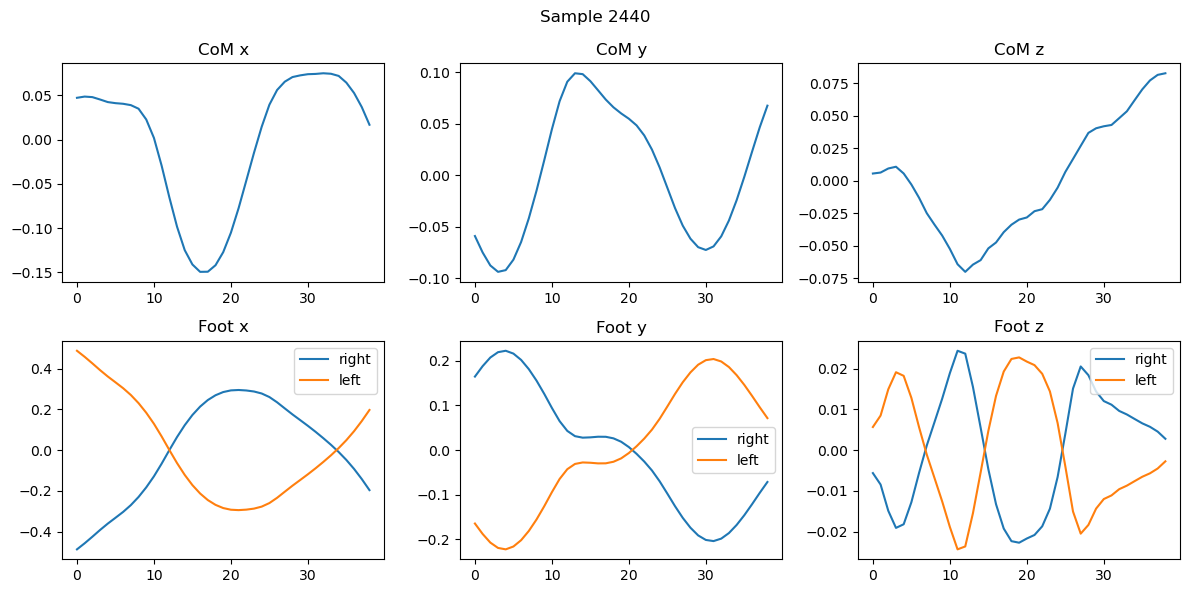

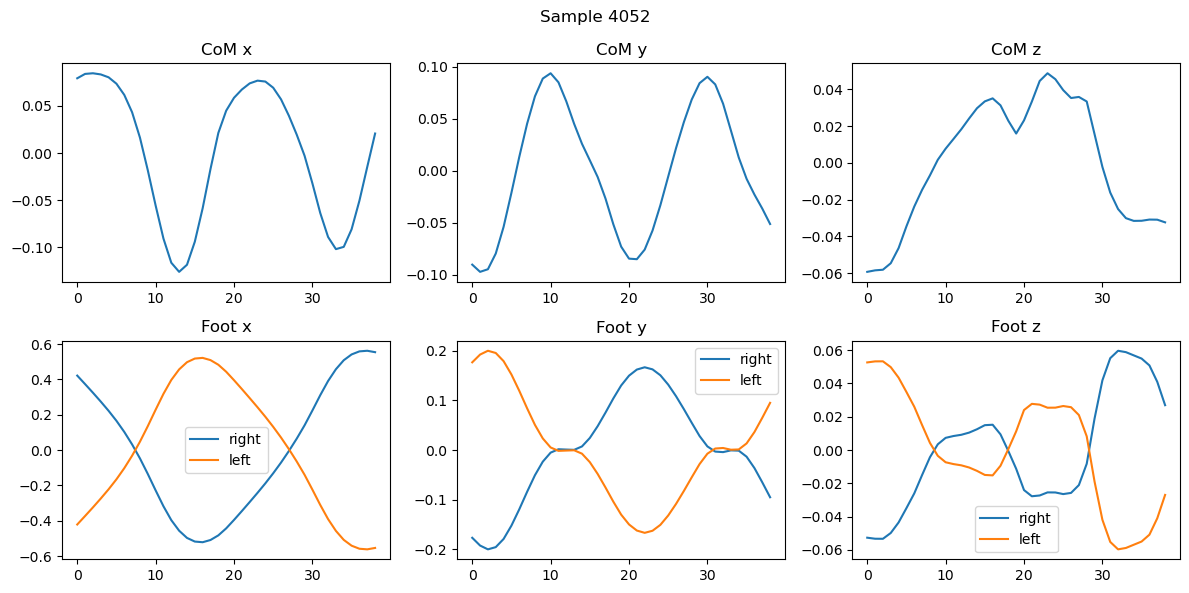

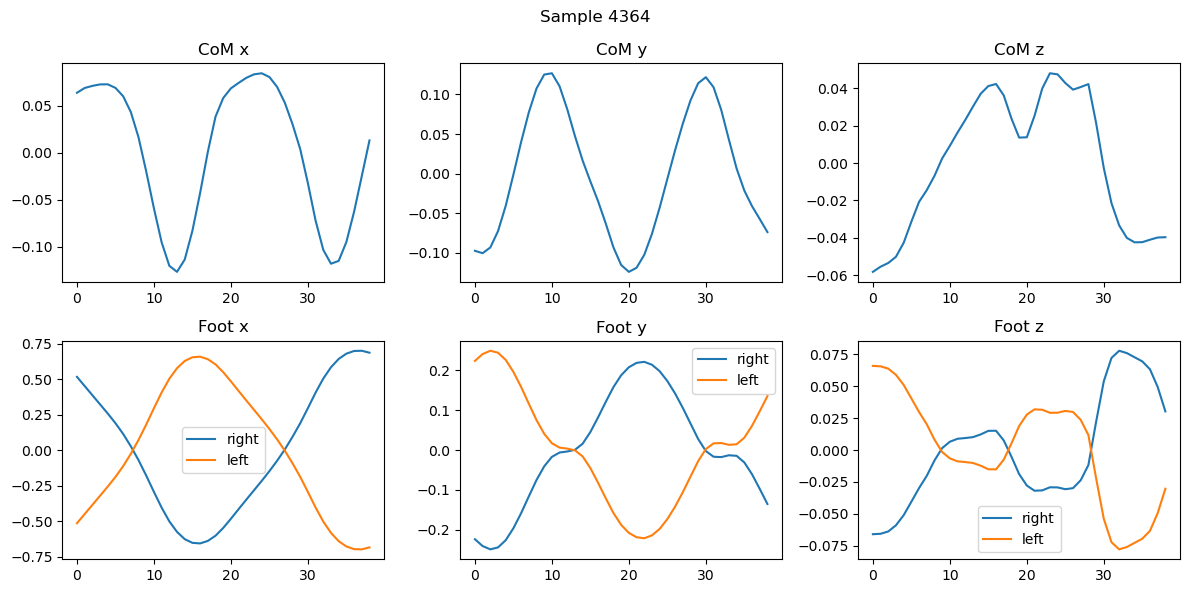

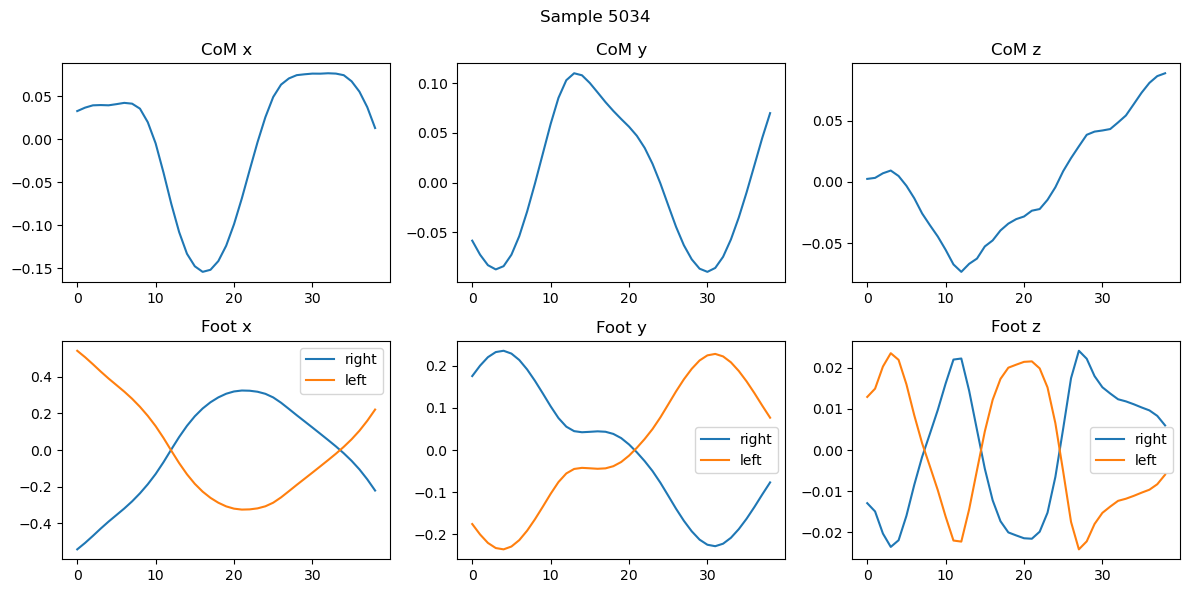

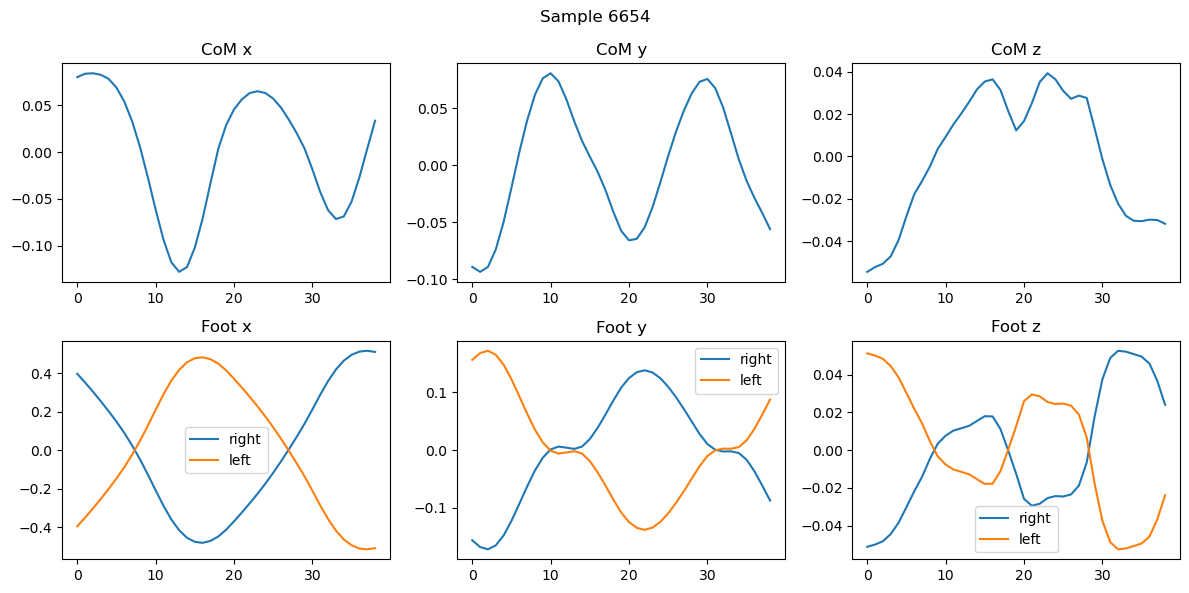

In [20]:
for i in range(5):
    idx = out_indices[i]
    plot_outlier_sequence(foot_train[idx], com_train[idx], idx)

In [13]:
tail_bound = compute_tail_bound(train_dataset, quantile=1, margin=1.2)

  theta abs-max:  mean=1.851, p99=3.364, p99.99=4.383
  → tail_bound = 5.786


In [14]:
T = train_dataset.dataset_foot[0].shape[0]
foot_input_size = T * 6

#### Tuning model hyperparameters

In [20]:
model = SplineFlowSummary(
        foot_input_size=foot_input_size,
        theta_dim=DIM_PCA_COM,
        condition_size=16,
        s_hidden=512,
        s_layers=4,
        f_hidden=256,
        f_blocks=24,
        num_bins=20,
        tail_bound=tail_bound,
).to("cuda")


In [1]:
from models.nsf import train_inn_cond

In [ ]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
lr_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        torch.optim.Adam(model.parameters(), lr=1e-3),
        mode='min',
        factor=0.5,
        patience=10
    )


In [ ]:
history = train_inn_cond(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    optim=optim,
    epochs=200, # original 50
    batch_size=250,
    lr_scheduler=lr_scheduler

)

Training:   0%|          | 1/200 [00:22<1:15:29, 22.76s/it, test_loss=10, train_loss=38.9]

Epoch 0 avg OOB rate: 0.0000


Training:   1%|          | 2/200 [00:45<1:14:21, 22.53s/it, test_loss=1.47, train_loss=5.77]

Epoch 1 avg OOB rate: 0.0000


Training:   2%|▏         | 3/200 [01:08<1:15:29, 22.99s/it, test_loss=-1.23, train_loss=-2.05]

...

Epoch 197 avg OOB rate: 0.0000


Training: 100%|█████████▉| 199/200 [1:12:26<00:22, 22.23s/it, test_loss=-15.2, train_loss=-16.8]

Epoch 198 avg OOB rate: 0.0000


Training: 100%|██████████| 200/200 [1:12:46<00:00, 21.83s/it, test_loss=-15.8, train_loss=-16.8]

Epoch 199 avg OOB rate: 0.0000


In [ ]:
# save model and training history
torch.save({
    'model_state_dict': model.state_dict(),
    'pca': pca,
    'theta_mean': theta_mean,
    'theta_std': theta_std,
    'train_history': history['train_loss'],
    'test_history': history['test_loss'],
    
}, "nsf_com_pca_model200epochs.pt")

In [15]:
checkpoint = torch.load("nsf_com_pca_model200epochs.pt", map_location="cpu", weights_only=False)
model_state_dict = checkpoint['model_state_dict']
pca = checkpoint['pca']
theta_mean = checkpoint['theta_mean']
theta_std = checkpoint['theta_std']
train_history = checkpoint['train_history']
test_history = checkpoint['test_history']
history = {
    'train_loss': train_history,
    'test_loss': test_history
}

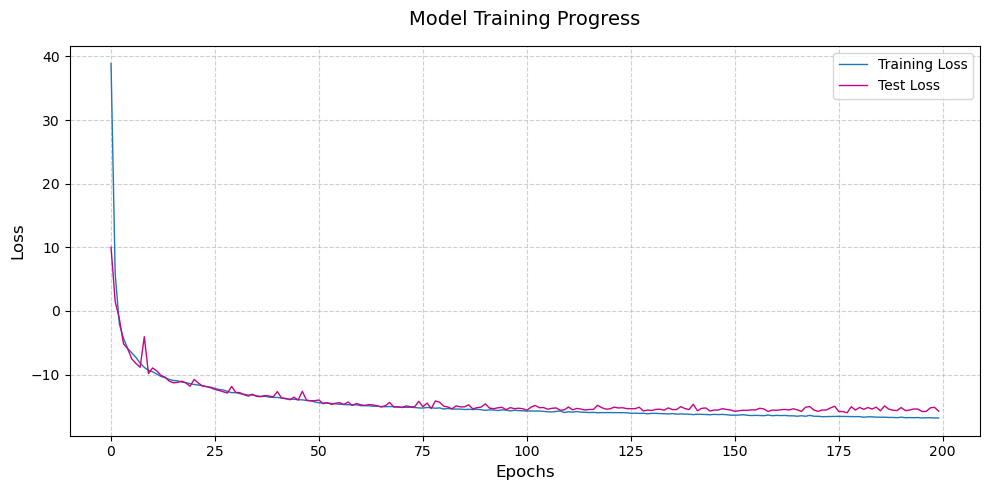

In [16]:
import matplotlib.pyplot as plt
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

In [ ]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
lr_scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(
        torch.optim.Adam(model.parameters(), lr=1e-3),
        mode='min',
        factor=0.5,
        patience=10
    )


In [ ]:
history = train_inn_cond(
    model=model,
    train_dataset=train_dataset,
    test_dataset=test_dataset,
    optim=optim,
    epochs=50,
    batch_size=250,
    lr_scheduler=lr_scheduler

)

Training:   2%|▏         | 1/50 [00:31<25:21, 31.05s/it, test_loss=12, train_loss=33.1]

Epoch 0 avg OOB rate: 0.0000


Training:   4%|▍         | 2/50 [01:03<25:23, 31.73s/it, test_loss=2.19, train_loss=5.5]

Epoch 1 avg OOB rate: 0.0000


Training:   6%|▌         | 3/50 [01:35<25:07, 32.07s/it, test_loss=-3.6, train_loss=-2.05]

...

Epoch 47 avg OOB rate: 0.0000


Training:  98%|█████████▊| 49/50 [26:20<00:32, 32.35s/it, test_loss=-14.5, train_loss=-14.7]

Epoch 48 avg OOB rate: 0.0000


Training: 100%|██████████| 50/50 [26:52<00:00, 32.24s/it, test_loss=-14.5, train_loss=-14.7]

Epoch 49 avg OOB rate: 0.0000


In [ ]:
# save model and training history
torch.save({
    'model_state_dict': model.state_dict(),
    'pca': pca,
    'theta_mean': theta_mean,
    'theta_std': theta_std,
    'train_history': history['train_loss'],
    'test_history': history['test_loss'],
    
}, "nsf_com_pca_model.pt")

In [15]:
import torch 
checkpoint = torch.load("nsf_com_pca_model.pt", map_location="cpu")


In [16]:
model = SplineFlowSummary(
        foot_input_size=foot_input_size,
        theta_dim=DIM_PCA_COM,
        condition_size=16,
        s_hidden=512,
        s_layers=4,
        f_hidden=256,
        f_blocks=24,
        num_bins=20,
        tail_bound=tail_bound,
).to("cpu")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

SplineFlowSummary(
  (summary): SummaryNetwork(
    (encoder): Sequential(
      (0): Linear(in_features=234, out_features=512, bias=True)
      (1): ReLU()
      (2): Linear(in_features=512, out_features=512, bias=True)
      (3): ReLU()
      (4): Linear(in_features=512, out_features=512, bias=True)
      (5): ReLU()
      (6): Linear(in_features=512, out_features=512, bias=True)
      (7): ReLU()
      (8): Linear(in_features=512, out_features=512, bias=True)
      (9): ReLU()
      (10): Linear(in_features=512, out_features=16, bias=True)
    )
  )
  (flow): SplineFlow(
    (coupling_blocks): ModuleList(
      (0-23): 24 x SplineCouplingBlock(
        (param_net): Sequential(
          (0): Linear(in_features=21, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=256, bias=True)
          (3): ReLU()
          (4): Linear(in_features=256, out_features=305, bias=True)
        )
      )
    )
    (linear_blocks): ModuleList(
      (

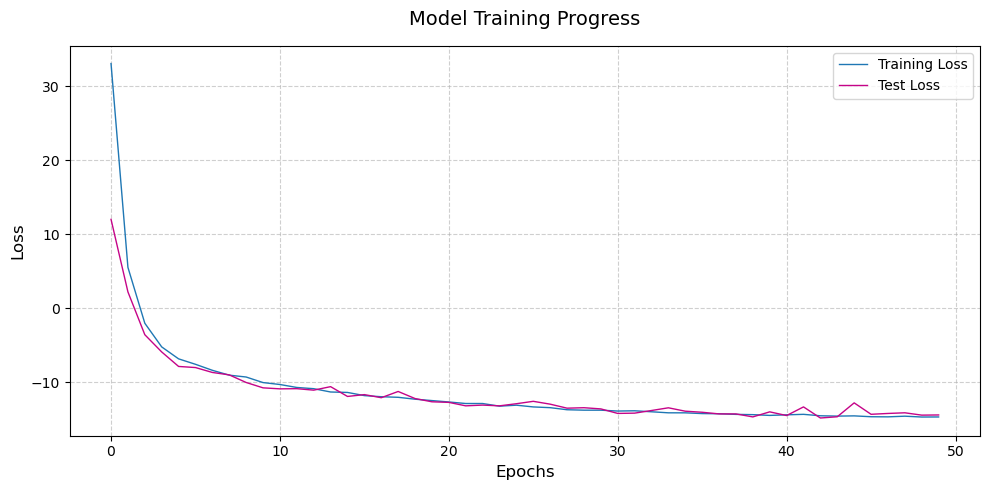

In [16]:
import matplotlib.pyplot as plt
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(checkpoint["train_history"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(checkpoint["test_history"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# Internal evaluation


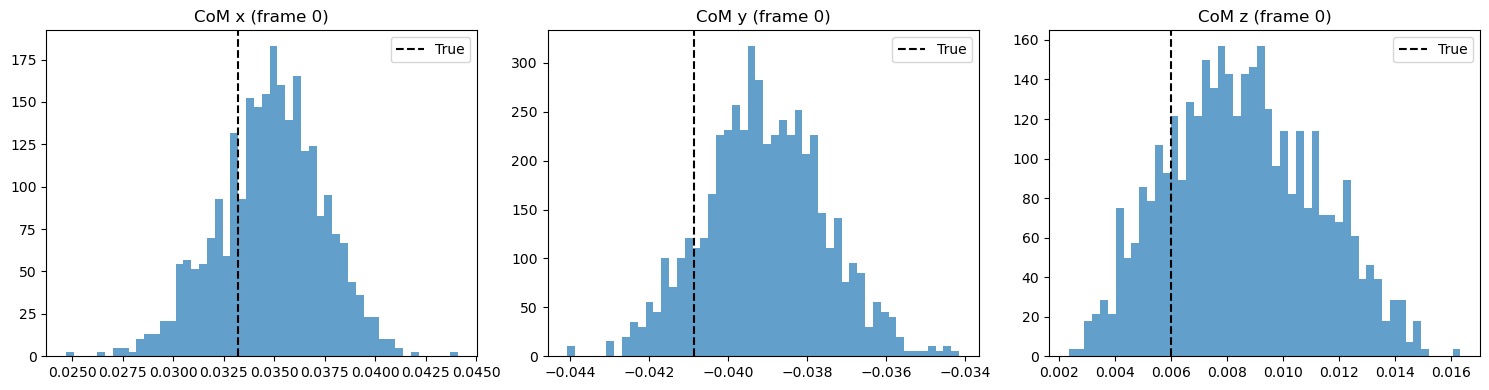

In [54]:
import matplotlib.pyplot as plt
#sample from test set
idx = 3
foot_sample, theta_true = test_dataset[idx]
foot_sample = foot_sample.unsqueeze(0).to("cpu")  # (1, foot_input_size)
n_samples = 1000

with torch.no_grad():
    theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()  # (n_samples, theta_dim)
com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)  # (n_samples, T*3)
com_samples = com_samples.reshape(n_samples, -1, 3)  # (n_samples, T, 3)

com_true = com_test[idx]  # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x (frame 0)", "CoM y (frame 0)", "CoM z (frame 0)"]
for d in range(3):
    #fixing time, t=0
    axes[d].hist(com_samples[:, 0, d], bins=50, density=True, alpha=0.7)
    axes[d].axvline(com_true[0, d], linestyle="--", color="k", label="True")
    axes[d].set_title(labels[d])
    axes[d].legend()
plt.tight_layout()
plt.show()

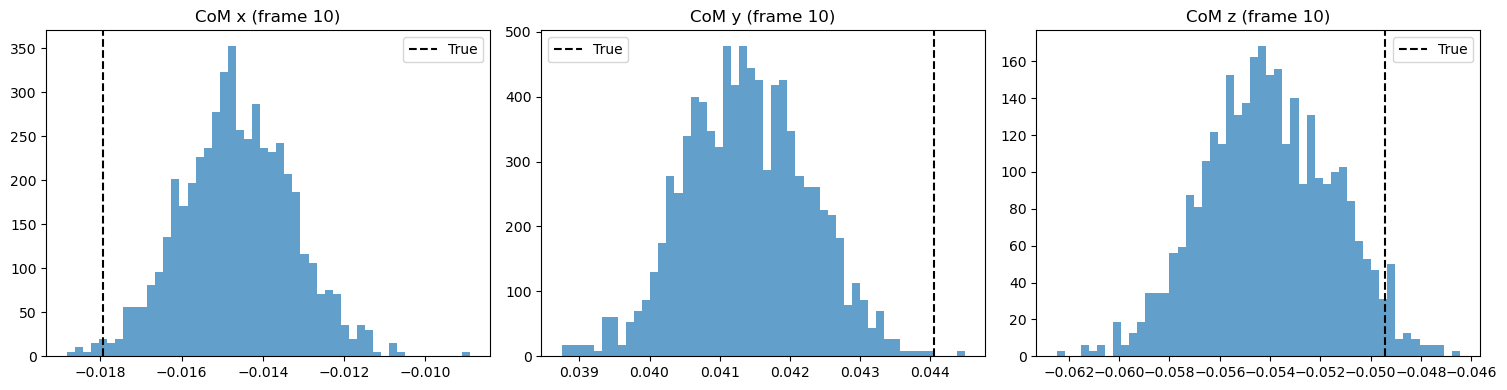

In [59]:
import matplotlib.pyplot as plt
#sample from test set
idx = 3
foot_sample, theta_true = test_dataset[idx]
foot_sample = foot_sample.unsqueeze(0).to("cpu")  # (1, foot_input_size)
n_samples = 1000

with torch.no_grad():
    theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()  # (n_samples, theta_dim)
com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)  # (n_samples, T*3)
com_samples = com_samples.reshape(n_samples, -1, 3)  # (n_samples, T, 3)

com_true = com_test[idx]  # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x (frame 10)", "CoM y (frame 10)", "CoM z (frame 10)"]
for d in range(3):
    #fixing time, t=10
    axes[d].hist(com_samples[:, 10, d], bins=50, density=True, alpha=0.7)
    axes[d].axvline(com_true[10, d], linestyle="--", color="k", label="True")
    axes[d].set_title(labels[d])
    axes[d].legend()
plt.tight_layout()
plt.show()

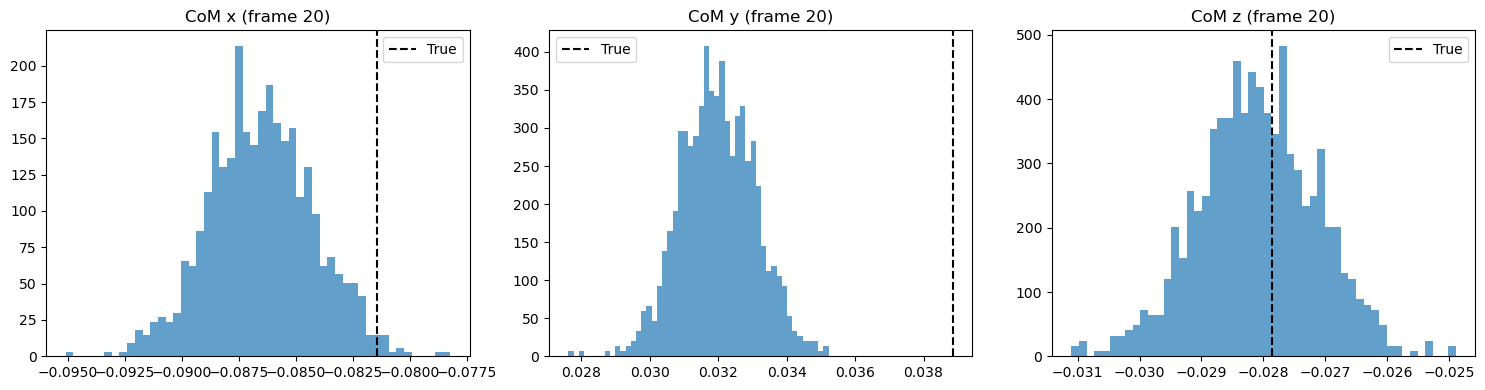

In [60]:
import matplotlib.pyplot as plt
#sample from test set
idx = 3
foot_sample, theta_true = test_dataset[idx]
foot_sample = foot_sample.unsqueeze(0).to("cpu")  # (1, foot_input_size)
n_samples = 1000

with torch.no_grad():
    theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()  # (n_samples, theta_dim)
com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)  # (n_samples, T*3)
com_samples = com_samples.reshape(n_samples, -1, 3)  # (n_samples, T, 3)

com_true = com_test[idx]  # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x (frame 20)", "CoM y (frame 20)", "CoM z (frame 20)"]
for d in range(3):
    #fixing time, t=20
    axes[d].hist(com_samples[:, 20, d], bins=50, density=True, alpha=0.7)
    axes[d].axvline(com_true[20, d], linestyle="--", color="k", label="True")
    axes[d].set_title(labels[d])
    axes[d].legend()
plt.tight_layout()
plt.show()

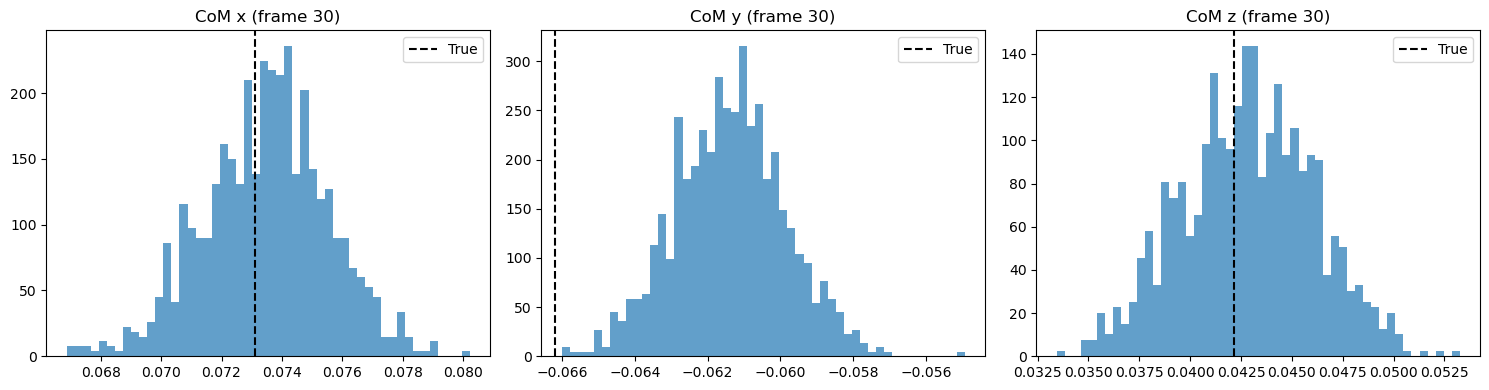

In [61]:
import matplotlib.pyplot as plt
#sample from test set
idx = 3
foot_sample, theta_true = test_dataset[idx]
foot_sample = foot_sample.unsqueeze(0).to("cpu")  # (1, foot_input_size)
n_samples = 1000

with torch.no_grad():
    theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()  # (n_samples, theta_dim)
com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)  # (n_samples, T*3)
com_samples = com_samples.reshape(n_samples, -1, 3)  # (n_samples, T, 3)

com_true = com_test[idx]  # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x (frame 30)", "CoM y (frame 30)", "CoM z (frame 30)"]
for d in range(3):
    #fixing time, t=30
    axes[d].hist(com_samples[:, 30, d], bins=50, density=True, alpha=0.7)
    axes[d].axvline(com_true[30, d], linestyle="--", color="k", label="True")
    axes[d].set_title(labels[d])
    axes[d].legend()
plt.tight_layout()
plt.show()

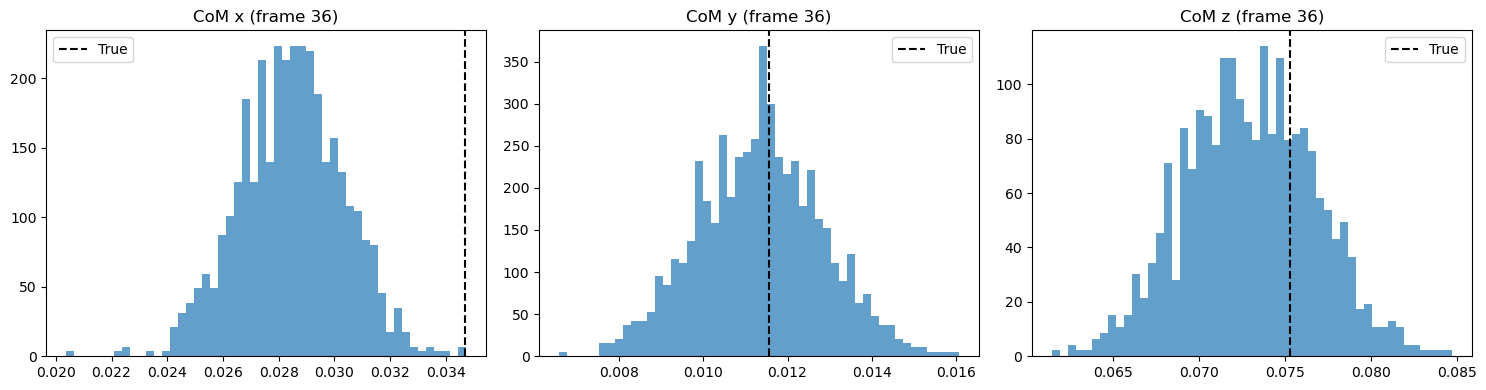

In [62]:
import matplotlib.pyplot as plt
#sample from test set
idx = 3
foot_sample, theta_true = test_dataset[idx]
foot_sample = foot_sample.unsqueeze(0).to("cpu")  # (1, foot_input_size)
n_samples = 1000

with torch.no_grad():
    theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()  # (n_samples, theta_dim)
com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)  # (n_samples, T*3)
com_samples = com_samples.reshape(n_samples, -1, 3)  # (n_samples, T, 3)

com_true = com_test[idx]  # (T, 3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["CoM x (frame 36)", "CoM y (frame 36)", "CoM z (frame 36)"]
for d in range(3):
    #fixing time, t=36
    axes[d].hist(com_samples[:, 36, d], bins=50, density=True, alpha=0.7)
    axes[d].axvline(com_true[36, d], linestyle="--", color="k", label="True")
    axes[d].set_title(labels[d])
    axes[d].legend()
plt.tight_layout()
plt.show()

In [44]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_posterior_trajectory(
    model,
    dataset,
    foot_data,
    com_data,
    pca,
    theta_mean,
    theta_std,
    idx=0,
    n_samples=2000,
    device="cpu",
):
    """
    Clean visualization:
    - white background
    - smooth posterior band (mean ± std)
    - clear feet trajectories
    """

    plt.style.use("default")

    # --- Get sample ---
    foot_sample, _ = dataset[idx]
    foot_sample = foot_sample.unsqueeze(0).to(device)

    foot_true = foot_data[idx]
    com_true  = com_data[idx]

    T = foot_true.shape[0]
    t = np.arange(T)

    # --- Sample posterior ---
    with torch.no_grad():
        theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()

    # --- Back to CoM space ---
    com_samples = pca.inverse_transform(theta_samples * theta_std + theta_mean)
    com_samples = com_samples.reshape(n_samples, T, 3)

    # --- Stats ---
    mean = com_samples.mean(axis=0)
    std  = com_samples.std(axis=0)

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

    dims = [
        ("Forward (x)", 0, 3),
        ("Vertical (y)", 1, 4),
        ("Lateral (z)", 2, 5),
    ]

    for ax, (title, d_com, d_foot2) in zip(axes, dims):

        # --- Feet (clean, slightly faded) ---
        ax.plot(t, foot_true[:, d_com],
                color="#1f77b4", linewidth=2, alpha=0.8, label="foot 1")
        ax.plot(t, foot_true[:, d_foot2],
                color="#2ca02c", linewidth=2, alpha=0.8, label="foot 2")

        # --- Posterior band (KEY IMPROVEMENT) ---
        ax.fill_between(
            t,
            mean[:, d_com] - std[:, d_com],
            mean[:, d_com] + std[:, d_com],
            color="blue",
            alpha=0.2,
            label="posterior ± std" if title == "Forward (x)" else None,
        )

        # --- Posterior mean ---
        ax.plot(t, mean[:, d_com],
                color="blue", linewidth=2)

        # --- True CoM ---
        ax.plot(t, com_true[:, d_com],
                color="red", linewidth=2.5, label="true CoM")

        ax.set_title(title)
        ax.grid(True, alpha=0.3)

    axes[0].legend()
    axes[-1].set_xlabel("time")

    plt.tight_layout()
    plt.show()

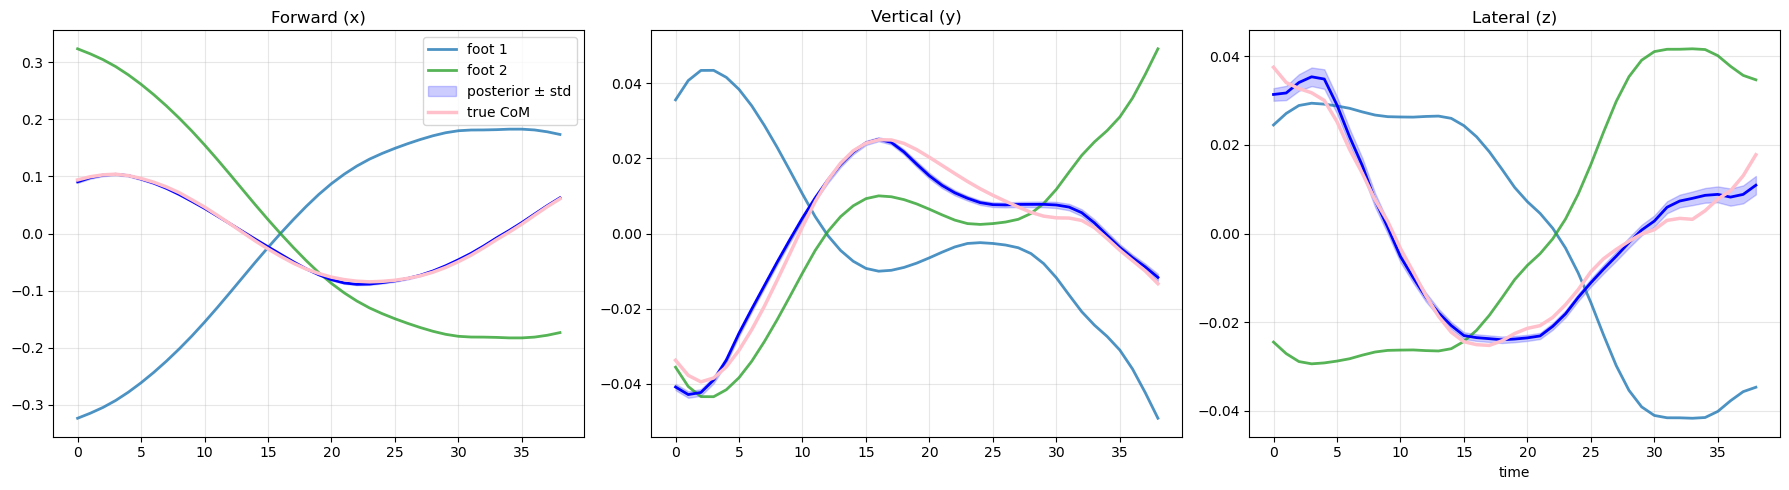

In [41]:
plot_posterior_trajectory(model, test_dataset, foot_test, com_test, pca, theta_mean, theta_std, idx=20)

In [45]:
def mean_euclidean_error(com_samples, com_true):
    """
    com_samples: (S, T, 3)
    com_true:    (T, 3)
    """

    mean = com_samples.mean(axis=0)  # (T, 3)

    # distance per timestep
    dist = np.linalg.norm(mean - com_true, axis=1)  # (T,)

    return dist.mean()

In [46]:
def evaluate_mean_error(
    model,
    dataset,
    com_data,
    pca,
    theta_mean,
    theta_std,
    n_samples=500,
    device="cpu",
):
    errors = []

    for idx in range(len(dataset)):
        foot_sample, _ = dataset[idx]
        foot_sample = foot_sample.unsqueeze(0).to(device)

        com_true = com_data[idx]

        with torch.no_grad():
            theta_samples = model.sample(foot_sample, n_samples).cpu().numpy()

        com_samples = pca.inverse_transform(
            theta_samples * theta_std + theta_mean
        ).reshape(n_samples, *com_true.shape)

        err = mean_euclidean_error(com_samples, com_true)
        errors.append(err)

    return np.mean(errors)

In [47]:
mean = evaluate_mean_error(model, test_dataset, com_test, pca, theta_mean, theta_std, n_samples=500)

In [48]:
print(mean)

0.006858063


In [49]:
from internal_validation import trajectory_energy_score

def evaluate_trajectory_energy(
    model,
    test_dataset,
    com_data,
    pca,
    theta_mean,
    theta_std,
    n_samples=200,
    device="cpu",
):
    scores = []

    for idx in range(len(test_dataset)):
        foot, _ = test_dataset[idx]
        foot = foot.unsqueeze(0).to(device)
        true_com = torch.tensor(com_data[idx], device=device)  # (T, 3)

        #sample com from posterior
        with torch.no_grad():
            theta_samples = model.sample(foot, n_samples)  # (S, theta_dim)
        theta_samples = theta_samples.cpu().numpy()
        trajs = pca.inverse_transform(
            theta_samples * theta_std + theta_mean
        ).reshape(n_samples, *true_com.shape)

        trajs = torch.tensor(trajs, device=device)  # (S, T, 3)

        score = trajectory_energy_score(trajs, true_com)

        scores.append(score.item())

    return sum(scores) / len(scores)

In [50]:
energy = evaluate_trajectory_energy(model, test_dataset, com_test, pca, theta_mean, theta_std, n_samples=200)

In [51]:
print(energy)

0.0380591460127073


calibration check

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def calibration_check(
    model,
    test_dataset,
    pca,
    theta_mean,
    theta_std,
    M=200,           # posterior samples per test point
    B=10,            # number of bins for histogram test
    N_test=None,     # how many test points to use (None = all)
    device="cpu",
):
    """
    Calibration check following the ECDF-based algorithm.
    For each test point i and each dimension j:
      - Draw M samples from posterior p(y|x_i)
      - Form dataset of size M+1: M samples + ground truth y_i*
      - Sort and find rank of y_i* among the M+1 values
      - Compute r_ij = rank / (M+2)  (relative position of GT)
    If model is perfect, {r_ij}_i are uniform in [0,1] for each j.
    """
    model.eval()
    model.to(device)

    N = len(test_dataset) if N_test is None else N_test
    theta_dim = test_dataset[0][1].shape[0]  # dimension of theta (PCA space)

    all_ranks = np.zeros((N, theta_dim))  # r_ij for each sample i, dim j

    with torch.no_grad():
        for i in range(N):
            foot_sample, theta_true = test_dataset[i]
            foot_sample = foot_sample.unsqueeze(0).to(device)   # (1, foot_dim)
            theta_true = theta_true.numpy()                      # (theta_dim,)

            # (a) sample M times from posterior
            theta_samples = model.sample(foot_sample, M).cpu().numpy()  # (M, theta_dim)

            # (b) form dataset of size M+1: samples ∪ {y_i*}
            combined = np.concatenate([theta_samples, theta_true[None, :]], axis=0)  # (M+1, theta_dim)

            # (c) for each dimension j, sort and find rank [m]* of y_i*
            for j in range(theta_dim):
                sorted_indices = np.argsort(combined[:, j])
                rank = np.where(sorted_indices == M)[0][0]  # index M is the ground truth
                all_ranks[i, j] = (rank) / (M + 2)         # r_ij = [m]* / (M+2)

    # ── TEST 1: Histogram test ──────────────────────────────────────────
    # If uniform, each bin should follow Binomial(N/B, N, 1/B)
    # expected count per bin = N/B, std = sqrt(N * 1/B * (1 - 1/B))
    expected = N / B
    std_binom = np.sqrt(N * (1/B) * (1 - 1/B))

    fig1, axes = plt.subplots(2, (theta_dim + 1) // 2, figsize=(4 * theta_dim, 6))
    axes = axes.flatten()
    for j in range(theta_dim):
        counts, edges = np.histogram(all_ranks[:, j], bins=B, range=(0, 1))
        bin_centers = (edges[:-1] + edges[1:]) / 2
        axes[j].bar(bin_centers, counts, width=1/B, alpha=0.7, label=f'dim {j}')
        axes[j].axhline(expected, color='k', linestyle='--', label='Expected')
        axes[j].axhline(expected + 2*std_binom, color='r', linestyle=':', label='±2σ')
        axes[j].axhline(expected - 2*std_binom, color='r', linestyle=':')
        axes[j].set_title(f'Dimension {j}')
        axes[j].set_xlabel('r_ij')
        axes[j].set_ylabel('Count')
        axes[j].legend(fontsize=7)
    plt.suptitle('Test 1: Histogram calibration check (should be flat)')
    plt.tight_layout()
    plt.show()

    # ── TEST 2: ECDF test ───────────────────────────────────────────────
    # Plot sqrt(N) * (ECDF_j(t) - t) — should stay within ±sqrt(t(1-t)) band
    t = np.linspace(0, 1, 300)
    band = np.sqrt(t * (1 - t))

    fig2, axes = plt.subplots(2, (theta_dim + 1) // 2, figsize=(4 * theta_dim, 6))
    axes = axes.flatten()
    for j in range(theta_dim):
        r_j = np.sort(all_ranks[:, j])
        # ECDF_j(t) = (1/N) * sum 1[r_ij <= t]
        ecdf = np.array([np.mean(r_j <= ti) for ti in t])
        curve = np.sqrt(N) * (ecdf - t)

        axes[j].plot(t, curve, label='√N·(ECDF-t)', linewidth=1.5)
        axes[j].fill_between(t, -band, band, alpha=0.2, color='gray', label='±√(t(1-t))')
        axes[j].axhline(0, color='k', linewidth=0.8)
        axes[j].set_title(f'Dimension {j}')
        axes[j].set_xlabel('t')
        axes[j].legend(fontsize=7)

        # color code: overconfident if curve exits top, underconfident if bottom
        if np.any(curve > band):
            axes[j].set_facecolor('#fff0f0')  # reddish = overconfident
        elif np.any(curve < -band):
            axes[j].set_facecolor('#f0f0ff')  # bluish = underconfident

    plt.suptitle('Test 2: ECDF calibration check (should stay within gray band)')
    plt.tight_layout()
    plt.show()

    # ── Summary: KS test p-values ───────────────────────────────────────
    print("\nKolmogorov-Smirnov uniformity test per dimension:")
    print(f"{'Dim':<6} {'KS stat':<12} {'p-value':<12} {'Calibrated?'}")
    print("-" * 45)
    for j in range(theta_dim):
        ks_stat, p_val = stats.kstest(all_ranks[:, j], 'uniform')
        calibrated = "✅" if p_val > 0.05 else "❌"
        print(f"{j:<6} {ks_stat:<12.4f} {p_val:<12.4f} {calibrated}")

    return all_ranks

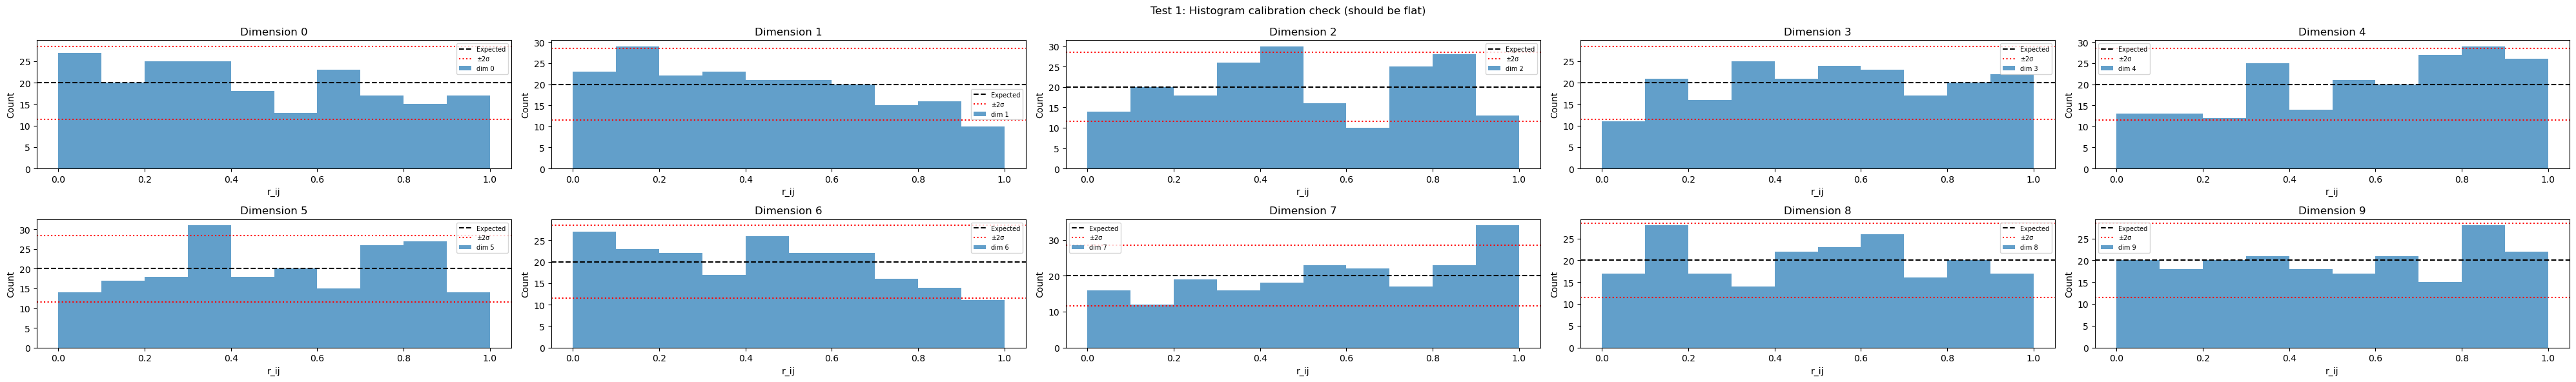

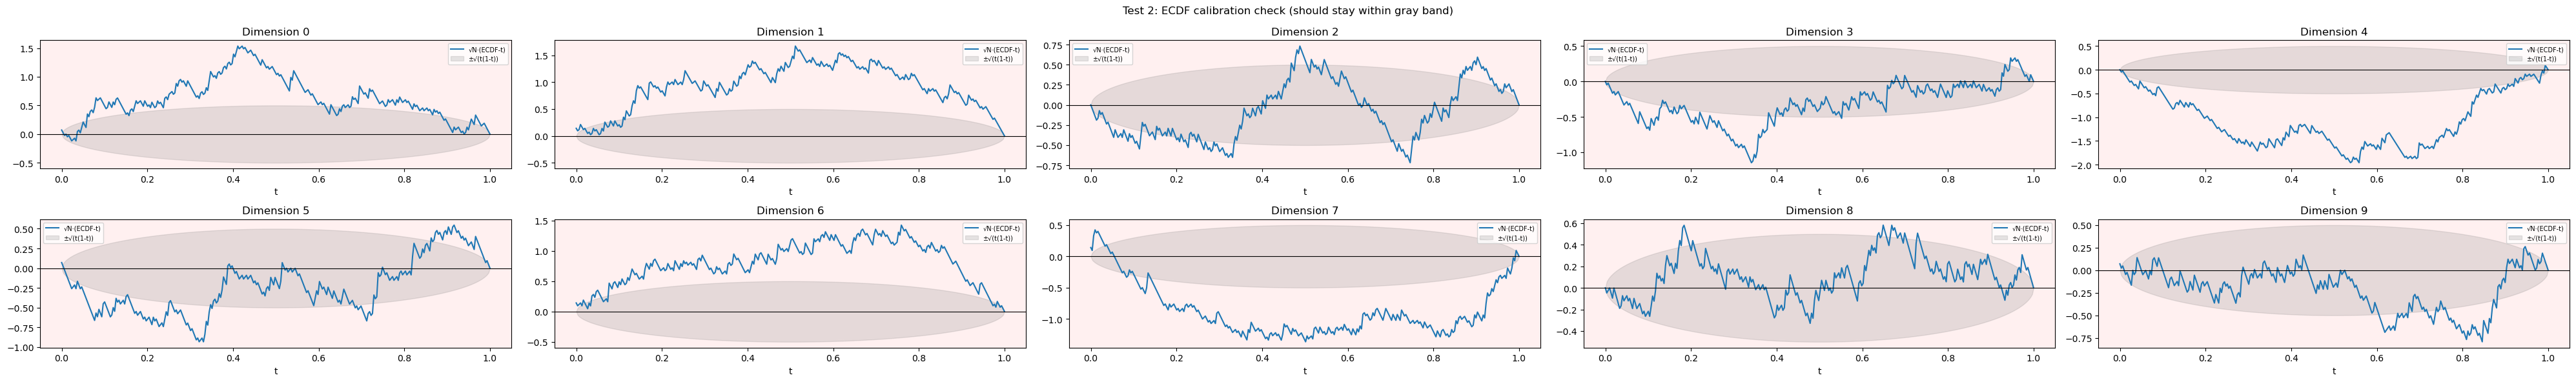


Kolmogorov-Smirnov uniformity test per dimension:
Dim    KS stat      p-value      Calibrated?
---------------------------------------------
0      0.1093       0.0156       ❌
1      0.1201       0.0057       ❌
2      0.0549       0.5651       ✅
3      0.0816       0.1320       ✅
4      0.1396       0.0007       ❌
5      0.0668       0.3192       ✅
6      0.1026       0.0276       ❌
7      0.1000       0.0342       ❌
8      0.0418       0.8605       ✅
9      0.0569       0.5185       ✅


In [65]:
all_ranks = calibration_check(
    model=model,
    test_dataset=test_dataset,
    pca=pca,
    theta_mean=theta_mean,
    theta_std=theta_std,
    M=200,      # posterior samples per test point
    B=10,       # histogram bins
    N_test=200, # use 200 test points (more = more reliable)
    device="cpu",
)

#### External validation

Resampling external data from 50 → 39 frames


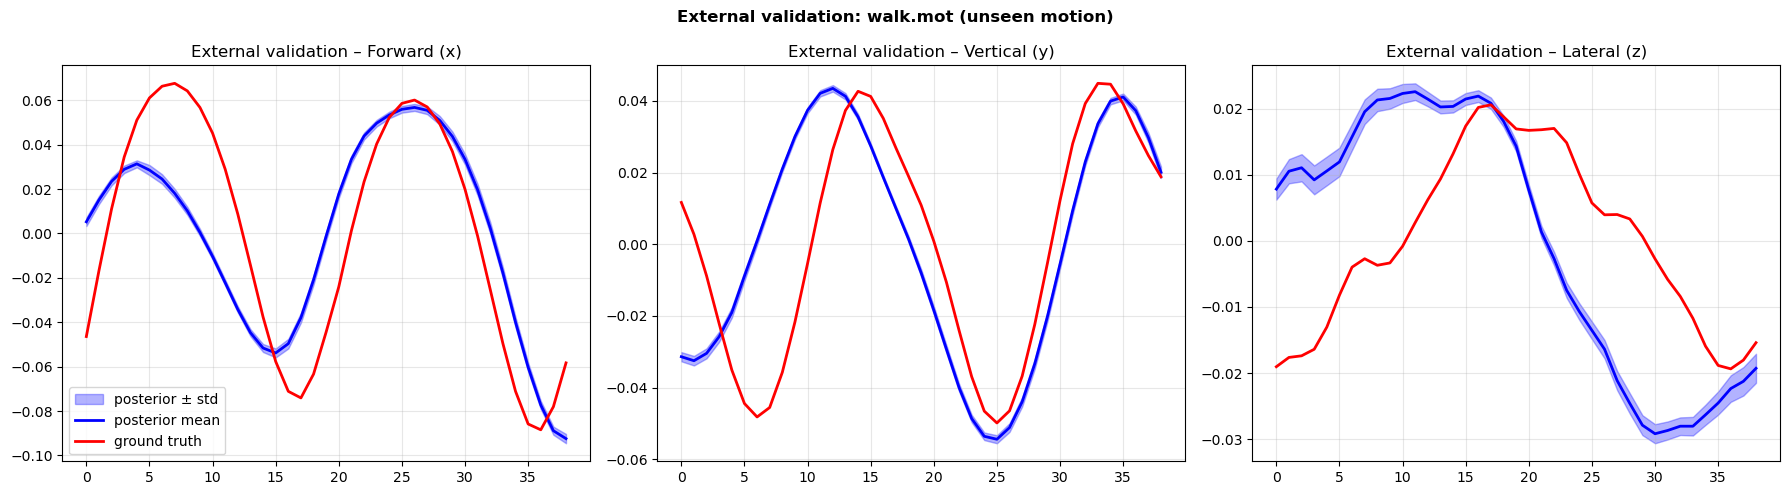

External validation mean Euclidean error: 4.004 cm


In [73]:
#External validation on normal.mot ─────────────────────────────────
import opensim as osim
from scipy.interpolate import interp1d

SAMPLE_RATE = 50  # match your training rate

device = "cpu"  # or "cuda" if you have a GPU and want to speed up sampling

def extract_kinematics_osim(model_path, mot_path, sample_rate=50):
    model = osim.Model(model_path)
    state = model.initSystem()

    table = osim.TimeSeriesTable(mot_path)
    proc  = osim.TableProcessor(table)
    try:
        if table.getTableMetaDataString("inDegrees").strip().lower() == "yes":
            proc.append(osim.TabOpConvertDegreesToRadians())
    except Exception:
        pass
    table = proc.process(model)

    coordSet = model.getCoordinateSet()
    labels   = table.getColumnLabels()
    coord_indices, coords = [], []
    for j in range(len(labels)):
        if coordSet.contains(labels[j]):
            coord_indices.append(j)
            coords.append(coordSet.get(labels[j]))

    foot_r = model.getBodySet().get("calcn_r")
    foot_l = model.getBodySet().get("calcn_l")

    N     = table.getNumRows()
    times = list(table.getIndependentColumn())
    foot_data = np.zeros((N, 6), dtype=np.float32)
    com_data  = np.zeros((N, 3), dtype=np.float32)

    for i in range(N):
        state.setTime(times[i])
        row = table.getRowAtIndex(i)
        for k, coord in enumerate(coords):
            coord.setValue(state, row[coord_indices[k]], False)
        model.realizePosition(state)
        pr = foot_r.getPositionInGround(state)
        pl = foot_l.getPositionInGround(state)
        foot_data[i] = [pr.get(0), pr.get(1), pr.get(2),
                        pl.get(0), pl.get(1), pl.get(2)]
        c = model.calcMassCenterPosition(state)
        com_data[i]  = [c.get(0), c.get(1), c.get(2)]

    # resample to sample_rate Hz
    times_arr = np.array(times, dtype=np.float64)
    t_new     = np.linspace(times_arr[0], times_arr[-1],
                            int((times_arr[-1] - times_arr[0]) * sample_rate))
    foot_data = interp1d(times_arr, foot_data, axis=0)(t_new).astype(np.float32)
    com_data  = interp1d(times_arr, com_data,  axis=0)(t_new).astype(np.float32)

    return t_new.astype(np.float32), foot_data, com_data


# --- Load normal.mot ---
times_ext, foot_ext_raw, com_ext_raw = extract_kinematics_osim(
    "gait2392_simbody.osim", "normal.mot", sample_rate=SAMPLE_RATE
)

# --- same normalization as training ---
foot_ext, com_ext = normalize_sequence_2(foot_ext_raw, com_ext_raw)

T_train = foot_input_size // 6
T_ext_raw = foot_ext.shape[0]
if T_ext_raw != T_train:
    print(f"Resampling external data from {T_ext_raw} → {T_train} frames")
    t_orig = np.linspace(0, 1, T_ext_raw)
    t_new  = np.linspace(0, 1, T_train)
    foot_ext = interp1d(t_orig, foot_ext, axis=0)(t_new).astype(np.float32)
    com_ext  = interp1d(t_orig, com_ext,  axis=0)(t_new).astype(np.float32)



# --- Build foot input vector (flatten, same as FootComDataset.__getitem__) ---
foot_tensor = torch.tensor(foot_ext.reshape(-1), dtype=torch.float32).unsqueeze(0)  # (1, T*6)

# --- Sample posterior ---
n_samples = 1000
model.eval()
with torch.no_grad():
    theta_samples = model.sample(foot_tensor.to(device), n_samples).cpu().numpy()  # (S, theta_dim)

# --- Back to CoM space ---
T_ext = com_ext.shape[0]
com_samples = pca.inverse_transform(
    theta_samples * theta_std + theta_mean
).reshape(n_samples, T_ext, 3)  # (S, T, 3)

# --- Plot: posterior mean ± std vs ground truth ---
mean_pred = com_samples.mean(axis=0)
std_pred  = com_samples.std(axis=0)
t = np.arange(T_ext)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Forward (x)", "Vertical (y)", "Lateral (z)"]
for i, ax in enumerate(axes):
    ax.fill_between(t, mean_pred[:, i] - std_pred[:, i],
                       mean_pred[:, i] + std_pred[:, i],
                    alpha=0.3, color="blue", label="posterior ± std")
    ax.plot(t, mean_pred[:, i], color="blue", lw=2, label="posterior mean")
    ax.plot(t, com_ext[:, i],   color="red",  lw=2, label="ground truth")
    ax.set_title(f"External validation – {titles[i]}")
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.suptitle("External validation: walk.mot (unseen motion)", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Mean Euclidean error ---
err = mean_euclidean_error(com_samples, com_ext)
print(f"External validation mean Euclidean error: {err*100:.3f} cm")

Resampling external data from 499 → 39 frames


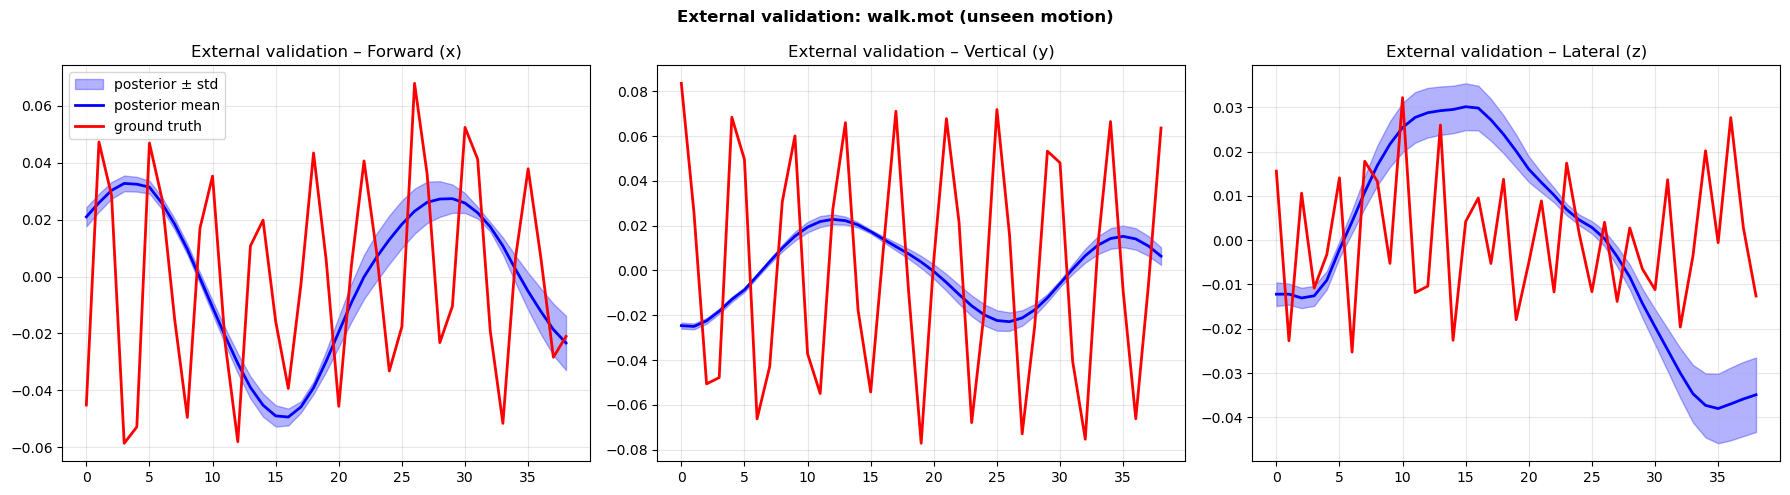

External validation mean Euclidean error: 6.967 cm


In [74]:
#External validation on running.mot ─────────────────────────────────
import opensim as osim
from scipy.interpolate import interp1d

SAMPLE_RATE = 50  # match your training rate

device = "cpu"  # or "cuda" if you have a GPU and want to speed up sampling

def extract_kinematics_osim(model_path, mot_path, sample_rate=50):
    model = osim.Model(model_path)
    state = model.initSystem()

    table = osim.TimeSeriesTable(mot_path)
    proc  = osim.TableProcessor(table)
    try:
        if table.getTableMetaDataString("inDegrees").strip().lower() == "yes":
            proc.append(osim.TabOpConvertDegreesToRadians())
    except Exception:
        pass
    table = proc.process(model)

    coordSet = model.getCoordinateSet()
    labels   = table.getColumnLabels()
    coord_indices, coords = [], []
    for j in range(len(labels)):
        if coordSet.contains(labels[j]):
            coord_indices.append(j)
            coords.append(coordSet.get(labels[j]))

    foot_r = model.getBodySet().get("calcn_r")
    foot_l = model.getBodySet().get("calcn_l")

    N     = table.getNumRows()
    times = list(table.getIndependentColumn())
    foot_data = np.zeros((N, 6), dtype=np.float32)
    com_data  = np.zeros((N, 3), dtype=np.float32)

    for i in range(N):
        state.setTime(times[i])
        row = table.getRowAtIndex(i)
        for k, coord in enumerate(coords):
            coord.setValue(state, row[coord_indices[k]], False)
        model.realizePosition(state)
        pr = foot_r.getPositionInGround(state)
        pl = foot_l.getPositionInGround(state)
        foot_data[i] = [pr.get(0), pr.get(1), pr.get(2),
                        pl.get(0), pl.get(1), pl.get(2)]
        c = model.calcMassCenterPosition(state)
        com_data[i]  = [c.get(0), c.get(1), c.get(2)]

    # resample to sample_rate Hz
    times_arr = np.array(times, dtype=np.float64)
    t_new     = np.linspace(times_arr[0], times_arr[-1],
                            int((times_arr[-1] - times_arr[0]) * sample_rate))
    foot_data = interp1d(times_arr, foot_data, axis=0)(t_new).astype(np.float32)
    com_data  = interp1d(times_arr, com_data,  axis=0)(t_new).astype(np.float32)

    return t_new.astype(np.float32), foot_data, com_data


# --- Load normal.mot ---
times_ext, foot_ext_raw, com_ext_raw = extract_kinematics_osim(
    "gait2392_simbody.osim", "running.mot", sample_rate=SAMPLE_RATE
)

# --- same normalization as training ---
foot_ext, com_ext = normalize_sequence_2(foot_ext_raw, com_ext_raw)

T_train = foot_input_size // 6
T_ext_raw = foot_ext.shape[0]
if T_ext_raw != T_train:
    print(f"Resampling external data from {T_ext_raw} → {T_train} frames")
    t_orig = np.linspace(0, 1, T_ext_raw)
    t_new  = np.linspace(0, 1, T_train)
    foot_ext = interp1d(t_orig, foot_ext, axis=0)(t_new).astype(np.float32)
    com_ext  = interp1d(t_orig, com_ext,  axis=0)(t_new).astype(np.float32)



# --- Build foot input vector (flatten, same as FootComDataset.__getitem__) ---
foot_tensor = torch.tensor(foot_ext.reshape(-1), dtype=torch.float32).unsqueeze(0)  # (1, T*6)

# --- Sample posterior ---
n_samples = 1000
model.eval()
with torch.no_grad():
    theta_samples = model.sample(foot_tensor.to(device), n_samples).cpu().numpy()  # (S, theta_dim)

# --- Back to CoM space ---
T_ext = com_ext.shape[0]
com_samples = pca.inverse_transform(
    theta_samples * theta_std + theta_mean
).reshape(n_samples, T_ext, 3)  # (S, T, 3)

# --- Plot: posterior mean ± std vs ground truth ---
mean_pred = com_samples.mean(axis=0)
std_pred  = com_samples.std(axis=0)
t = np.arange(T_ext)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ["Forward (x)", "Vertical (y)", "Lateral (z)"]
for i, ax in enumerate(axes):
    ax.fill_between(t, mean_pred[:, i] - std_pred[:, i],
                       mean_pred[:, i] + std_pred[:, i],
                    alpha=0.3, color="blue", label="posterior ± std")
    ax.plot(t, mean_pred[:, i], color="blue", lw=2, label="posterior mean")
    ax.plot(t, com_ext[:, i],   color="red",  lw=2, label="ground truth")
    ax.set_title(f"External validation – {titles[i]}")
    ax.grid(True, alpha=0.3)
axes[0].legend()
plt.suptitle("External validation: walk.mot (unseen motion)", fontweight="bold")
plt.tight_layout()
plt.show()

# --- Mean Euclidean error ---
err = mean_euclidean_error(com_samples, com_ext)
print(f"External validation mean Euclidean error: {err*100:.3f} cm")

#### tuning model parameters

In [63]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def run_experiment(config):

    # --- PCA
    pca, theta_mean, theta_std = fit_com_pca(
        com_train,
        theta_dim=config["pca_dim"]
    )

    # --- datasets
    train_dataset = FootComDataset(
        dataset_foot=foot_train,
        dataset_com=com_train,
        pca=pca,
        theta_mean=theta_mean,
        theta_std=theta_std,
    )

    test_dataset = FootComDataset(
        dataset_foot=foot_test,
        dataset_com=com_test,
        pca=pca,
        theta_mean=theta_mean,
        theta_std=theta_std,
    )

    # --- model
    model = SplineFlowSummary(
        foot_input_size=foot_input_size,
        theta_dim=config["pca_dim"],
        condition_size=config["condition_size"],
        s_hidden=config["s_hidden"],
        s_layers=config["s_layers"],
        f_hidden=config["f_hidden"],
        f_blocks=config["f_blocks"],
        num_bins=8,
        tail_bound=100.0,
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])

    history = train_inn_cond(
        model=model,
        train_dataset=train_dataset,
        test_dataset=test_dataset,
        optim=optimizer,
        epochs=config["epochs"],
        batch_size=config["batch_size"]
    )

    val_loss = min(history["test_loss"])

    return val_loss, model, pca, theta_mean, theta_std, history

In [6]:
def save_best(model, config, pca, theta_mean, theta_std, val_loss, history, name):
    torch.save({
        "model_state": model.state_dict(),
        "config": config,
        "pca": pca,
        "theta_mean": theta_mean,
        "theta_std": theta_std,
        "val_loss": val_loss,
    }, f"best_{name}.pt")

### PCA DIMENSION

In [ ]:
base_config = {
    "pca_dim": 8,
    "f_blocks": 3,
    "f_hidden": 256,
    "s_hidden": 512,
    "s_layers": 4,
    "condition_size": 16,
    **FAST_TRAIN
}

pca_values = [5, 8, 10, 12]

best_loss = float("inf")
best_config = None

for d in pca_values:
    config = base_config.copy()
    config["pca_dim"] = d

    print(f"\nPCA dim = {d}")

    val_loss, model, pca, mean, std, history = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, history, "pca")

print("Best PCA:", best_config["pca_dim"])


PCA dim = 5


Training: 100%|██████████| 30/30 [03:02<00:00,  6.10s/it, test_loss=-7.22, train_loss=-6.77]



PCA dim = 8


Training: 100%|██████████| 30/30 [03:04<00:00,  6.16s/it, test_loss=-10.3, train_loss=-10.5]



PCA dim = 10


Training: 100%|██████████| 30/30 [03:01<00:00,  6.07s/it, test_loss=-9.85, train_loss=-10.6]



PCA dim = 12


Training: 100%|██████████| 30/30 [03:03<00:00,  6.10s/it, test_loss=-10.5, train_loss=-10]  

Best PCA: 10


### Summary network

In [93]:
summary_grid = [
    {"s_hidden": 256, "condition_size": 16},
    {"s_hidden": 512, "condition_size": 16},
    {"s_hidden": 512, "condition_size": 32},
]

best_loss = float("inf")

for params in summary_grid:
    config = best_config.copy()
    config.update(params)

    print(f"\nSummary params: {params}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "summary")


Summary params: {'s_hidden': 256, 'condition_size': 16}


Training: 100%|██████████| 30/30 [03:01<00:00,  6.03s/it, test_loss=-7.85, train_loss=-8.29]



Summary params: {'s_hidden': 512, 'condition_size': 16}


Training: 100%|██████████| 30/30 [02:59<00:00,  6.00s/it, test_loss=-9.2, train_loss=-9.97] 



Summary params: {'s_hidden': 512, 'condition_size': 32}


Training: 100%|██████████| 30/30 [03:00<00:00,  6.00s/it, test_loss=-10.2, train_loss=-10.4]


Neural spline flow network

In [101]:
flow_grid = [
    {"f_blocks": 3, "f_hidden": 256},
    {"f_blocks": 5, "f_hidden": 256},
    {"f_blocks": 5, "f_hidden": 512},
]

best_loss = float("inf")

for params in flow_grid:
    config = best_config.copy()
    config.update(params)

    print(f"\nFlow params: {params}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "flow")


Flow params: {'f_blocks': 3, 'f_hidden': 256}


Training: 100%|██████████| 30/30 [03:00<00:00,  6.01s/it, test_loss=-8.52, train_loss=-6.7]  



Flow params: {'f_blocks': 5, 'f_hidden': 256}


Training:   0%|          | 0/30 [00:00<?, ?it/s]


InputOutsideDomain: 

In [2]:
import torch
from torch import device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

files = ["best_pca.pt", "best_summary.pt", "best_flow.pt"]

results = []

for f in files:
    ckpt = torch.load(f, map_location=device)
    results.append((f, ckpt["val_loss"], ckpt["config"]))

# sort by loss
results.sort(key=lambda x: x[1])

for f, loss, config in results:
    print(f"\nFile: {f}")
    print(f"Val loss: {loss:.4f}")
    print("Config:", config)


File: best_pca.pt
Val loss: -11.0265
Config: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 16, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}

File: best_summary.pt
Val loss: -10.4645
Config: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 32, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}

File: best_flow.pt
Val loss: -8.5190
Config: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 32, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}


BEST HYPERPARAMETERS MODEL: {'pca_dim': 10, 'f_blocks': 3, 'f_hidden': 256, 's_hidden': 512, 's_layers': 4, 'condition_size': 16, 'epochs': 30, 'batch_size': 256, 'lr': 0.0005}

In [ ]:
base_config = {
    "pca_dim": 10,
    "f_blocks": 3,
    "f_hidden": 256,
    "s_hidden": 512,
    "s_layers": 4,
    "condition_size": 16,
    "epochs": 200,
    "batch_size": 256,
    "lr": 1e-3
}

batch_size = [32, 64, 128, 256]

best_loss = float("inf")
best_config = None

for d in batch_size:
    config = base_config.copy()
    config["batch_size"] = d

    print(f"\nBatch size = {d}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "pca")

print("Best batch size:", best_config["batch_size"])

In [ ]:
learningrate = [1e-4, 5e-4, 1e-3, 5e-3]

best_loss = float("inf")
best_config = None

for lr in learningrate:
    config = base_config.copy()
    config["lr"] = lr

    print(f"\nLearning rate = {lr}")

    val_loss, model, pca, mean, std = run_experiment(config)

    if val_loss < best_loss:
        best_loss = val_loss
        best_config = config

        save_best(model, config, pca, mean, std, val_loss, "pca")

print("Best learning rate:", best_config["lr"])

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

file = torch.load("best_pca.pt", map_location=device)
loss = file["val_loss"]
print(f"Val loss: {loss:.4f}")


Val loss: -11.0265


In [ ]:
import matplotlib.pyplot as plt
model.to(device)
model.eval()
# 1. Set a clean style
plt.style.use('seaborn-v0_8-muted') # or 'ggplot'
plt.figure(figsize=(10, 5), dpi=100)

# 2. Plot with better aesthetics
plt.plot(np.array(loss_history["train_loss"][:]), 
         color='#1f77b4',       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Training Loss')

plt.plot(np.array(loss_history["test_loss"][:]), 
         color="#c50488",       # A nice professional blue
         linewidth=1,           # Slightly thicker line
         label='Test Loss')


# 3. Add context and labels
plt.title('Model Training Progress', fontsize=14, pad=15)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)

# 4. Clean up the "frame"
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()